# 01 · Construct real-event and tracker-error pairs

**The skeleton can be the same even when its meaning differs.** We build
matched cases where one video supports the apparent movement and another
does not. This is the simplest test of whether additional image evidence
is useful.

Run each notebook in a fresh kernel, in order **00 → 04**. Notebook 05 is
an external visual stress test. These are offline restoration experiments:
the model may inspect the declared complete clip. They do not claim causal
forecasting or clinical diagnosis.

**The default is real data.** Export `MP_RUN_ROOT`, the AMASS and GAVD data
paths, and the model configuration before opening Jupyter. See the
[launch guide](../../../../../slurm/motion-preservation/README.md).
For a CPU walkthrough of the mechanics, explicitly choose `MP_MODE=demo`
and a separate run directory. Demo outputs cannot establish a research result.

[Proposal](../../../../../docs/studies/motion-preservation/protocol/proposal.md)
· [Notebook guide](../../../../../notebooks/motion_preservation/README.md)

In [1]:
from pathlib import Path
import json
import os
import sys
from time import perf_counter

project_override = os.environ.get("GAVD6_ROOT")
candidates = ([Path(project_override).expanduser()] if project_override else
              [Path.cwd(), *Path.cwd().parents])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / "src/gavd6_sjepa").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set GAVD6_ROOT to the gavd6 checkout.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)  # Resolve manifest/config paths from the checkout in every kernel.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, Video, display
from gavd6_sjepa.research_directions.motion_preservation import workflow, plots

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 3.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
cfg = workflow.config_from_environment()
RUN_ROOT = Path(cfg.run_root)
print(f"Mode: {cfg.mode}; run directory: {RUN_ROOT}")
if cfg.mode == "demo":
    display(Markdown("**DEMO ONLY: generated fixtures and stand-in models. "
                     "These outputs are not evidence about AMASS, GAVD, or a pretrained prior.**"))

Mode: real; run directory: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/motion-preservation/pilot-01


## 1. Begin with a known motion and an edited motion

Let `x` be clean motion. Let `x_event` contain a smooth joint-angle edit,
converted to joint positions by forward kinematics. This keeps the
declared bone lengths fixed. The edit is a controlled motion event, not
a simulated medical diagnosis.

For a matched pair, the observed skeleton `z`, confidence, timestamps and
camera metadata are identical. Only the rendered evidence differs:

| Case | Rendered movement | Correct reference | Observed skeleton |
| --- | --- | --- | --- |
| Real event | `x_event` | `x_event` | the same `z` |
| Tracker error | `x` | `x` | the same `z` |

A skeleton-only method has no information that separates these two
cases. That is intentional. The pixels are the additional input.

## 2. Build the development data only

The same generation stage also crosses true event presence with
independent tracking noise. Event and noise can affect the same joint
at the same time. Without those mixed cases, a clip-level switch could
appear to solve the task.

This call creates train, calibration and development cases. It does not
generate final-test cases. The stage saves an index and per-case arrays
so later notebooks use exactly these observations.

In [2]:
development_roles = ("train", "calibration", "development")
started = perf_counter()
cases = workflow.build_pairs(cfg, roles=development_roles)
print(f"Built/loaded {len(cases):,} cases in {perf_counter() - started:.1f} seconds.")
display(cases.head(16))

train: built 1/8 motions (8 cases), 49.1s


train: built 2/8 motions (8 cases), 43.2s


train: built 3/8 motions (8 cases), 41.4s


train: built 4/8 motions (8 cases), 37.8s


train: built 5/8 motions (8 cases), 39.7s


...

development: built 6/8 motions (8 cases), 37.0s


development: built 7/8 motions (8 cases), 39.4s


development: built 8/8 motions (8 cases), 40.9s


Built/loaded 176 cases in 893.3 seconds.


,case_id,role,person_id,identity,event_family,family,fixture,event_present,noise_present,source_dataset,relative_path,scene_id,path,corruption,appearance,fps,event_magnitude,mode,render_seconds
0,train_0000_KIT__675_factorial_event0_noise0,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,False,False,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_event0,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.101538
1,train_0000_KIT__675_factorial_event0_noise1,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,False,True,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_event0,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.104490
2,train_0000_KIT__675_factorial_event1_noise0,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,True,False,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_event1,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.107695
3,train_0000_KIT__675_factorial_event1_noise1,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,factorial,True,True,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_event1,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.111019
4,train_0000_KIT__675_matched_real,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,matched,True,True,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_event1,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.114161
5,train_0000_KIT__675_matched_tracking_failure,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,matched,False,True,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_event0,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.117284
6,train_0000_KIT__675_matched_real_ambiguous,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,ambiguous,True,True,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_occluded,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.119949
7,train_0000_KIT__675_matched_tracking_failure_a...,train,KIT::675,KIT::675,arm_leg_timing,arm_leg_timing,ambiguous,False,True,KIT,KIT/675/walk_with_handrail_beam_right04_poses.npz,train_0000_KIT__675_occluded,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textured,20.0,0.148889,real,49.122971
8,train_0001_KIT__3_factorial_event0_noise0,train,KIT::3,KIT::3,arm_leg_timing,arm_leg_timing,factorial,False,False,KIT,KIT/3/squat01_poses.npz,train_0001_KIT__3_event0,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textureless,20.0,-0.062029,real,43.150300
9,train_0001_KIT__3_factorial_event0_noise1,train,KIT::3,KIT::3,arm_leg_timing,arm_leg_timing,factorial,False,True,KIT,KIT/3/squat01_poses.npz,train_0001_KIT__3_event0,/hai/scratch/tedmui/alexpose/experiments/sjepa...,burst,textureless,20.0,-0.062029,real,43.153321


In [3]:
# Inspect available design columns instead of inferring balance from totals.
design_columns = [c for c in ("role", "split", "fixture", "event_family", "event_present",
                               "noise_present", "corruption", "condition") if c in cases]
if design_columns:
    display(cases.groupby(design_columns, dropna=False).size().rename("cases").to_frame())
group_column = next((c for c in ("identity", "subject_id", "subject_id_candidate", "person_id")
                     if c in cases), None)
role_column = next((c for c in ("role", "split") if c in cases), None)
if group_column and role_column:
    display(cases.groupby(role_column)[group_column].nunique().rename("people_or_groups").to_frame())

cases
role        fixture   event_family   event_present noise_present corruption        
calibration ambiguous foot_clearance False         True          burst            4
                                                                 oscillation      4
                                     True          True          burst            4
                                                                 oscillation      4
            factorial foot_clearance False         False         burst            4
                                                                 oscillation      4
                                                   True          burst            4
                                                                 oscillation      4
                                     True          False         burst            4
                                                                 oscillation      4
                                                   True          burst            4
                                                                 oscillation      4
            matched   foot_clearance False         True          burst            4
                                                                 oscillation      4
                                     True          True          burst            4
                                                                 oscillation      4
development ambiguous foot_clearance False         True          burst            4
                                                                 oscillation      4
                                     True          True          burst            4
                                                                 oscillation      4
            factorial foot_clearance False         False         burst            4
                                                                 oscillation      4
                                                   True          burst            4
                                                                 oscillation      4
                                     True          False         burst            4
                                                                 oscillation      4
                                                   True          burst            4
                                                                 oscillation      4
            matched   foot_clearance False         True          burst            4
                                                                 oscillation      4
                                     True          True          burst            4
                                                                 oscillation      4
train       ambiguous arm_leg_timing False         True          burst            4
                                                                 oscillation      2
                                     True          True          burst            4
                                                                 oscillation      2
            factorial arm_leg_timing False         False         burst            4
                                                                 oscillation      2
                                                   True          burst            4
                                                                 oscillation      2
                                     True          False         burst            4
                                                                 oscillation      2
                                                   True          burst            4
                                                                 oscillation      2
            matched   arm_leg_timing False         True          burst            4
                                                                 oscillation      2
                                     True     

,people_or_groups
role,
calibration,8
development,8
train,6


## 3. Inspect a motion before fitting a model

The preview compares clean reference, edited reference and observations.
Inspect the timing, amplitude and affected joints. A smooth edit should
preserve the skeleton's lengths without creating an obvious boundary
spike that trivially gives away the event label.

Real mode renders the SMPL-H triangle mesh; demo mode uses procedural
articulated tubes. Material-point transport supplies the rendering
reference. The simple texture, camera and occluder do not simulate
realistic clothing or clinical pathology. Natural-video transfer remains
a separate requirement.

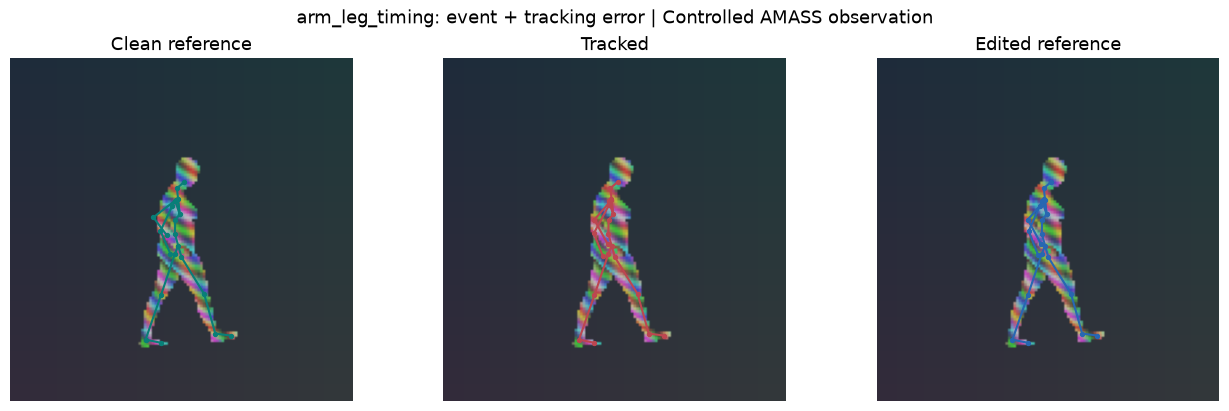

In [4]:
figure = plots.preview_pair(cfg, split="train")
display(figure)
plt.close(figure)

## 4. Inspect the controls that make the result meaningful

The important controls are scientific: identical paired skeleton inputs;
no person split across roles; both event and error in the same clip;
and an occluded pair where every model input is identical but the hidden
explanation differs. For that balanced ambiguous pair, a probability near
one half is appropriate. A confident decision is a failure.

Duration, centroid drift, foreground area and amplitude summaries should
not reveal the hidden explanation in the matched pair. Across other
conditions, summarize these nuisance variables and evaluate simple
baselines before interpreting a learned advantage.

In [5]:
control_columns = [c for c in cases if any(word in c.lower()
                   for word in ("pair", "identical", "occlu", "ambig", "camera", "noise", "event"))]
display(cases[control_columns].head(20) if control_columns else cases.head(20))
print("Final-test cases were not requested by this notebook.")

,event_family,event_present,noise_present,event_magnitude
0,arm_leg_timing,False,False,0.148889
1,arm_leg_timing,False,True,0.148889
2,arm_leg_timing,True,False,0.148889
3,arm_leg_timing,True,True,0.148889
4,arm_leg_timing,True,True,0.148889
5,arm_leg_timing,False,True,0.148889
6,arm_leg_timing,True,True,0.148889
7,arm_leg_timing,False,True,0.148889
8,arm_leg_timing,False,False,-0.062029
9,arm_leg_timing,False,True,-0.062029


Final-test cases were not requested by this notebook.


## Decision

Continue only if the generated changes are interpretable and the matched
cases force the method to use measurement evidence. If a trivial scalar
separates event from error, fix the construction before training.

Next: [02 · Cache the prior, flow, and baselines](02_prior_flow_and_baselines.ipynb).